In [1]:
import os
import pandas as pd
import numpy as np

# Construct the file path using os.path.join
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop")
file_path = os.path.join(desktop_path, "data", "Portfolios_Formed_on_ME_monthly_EW.csv")

# Read the CSV file into a DataFrame
me_m = pd.read_csv(file_path , header=0 , index_col=0 , parse_dates =True , na_values=-99.99)

<AxesSubplot:>

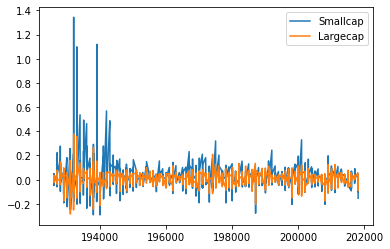

In [2]:
rets=me_m[['Lo 10', 'Hi 10']]
rets = rets/100
rets.columns = ['Smallcap','Largecap']
rets.plot.line()

In [3]:
rets.index = pd.to_datetime(rets.index, format='%Y%m')
rets.head()

,Smallcap,Largecap
1926-07-01,-0.0145,0.0329
1926-08-01,0.0512,0.0370
1926-09-01,0.0093,0.0067
1926-10-01,-0.0484,-0.0243
1926-11-01,-0.0078,0.0270


In [4]:
rets.index = rets.index.to_period('M')

In [5]:
rets.head()

,Smallcap,Largecap
1926-07,-0.0145,0.0329
1926-08,0.0512,0.0370
1926-09,0.0093,0.0067
1926-10,-0.0484,-0.0243
1926-11,-0.0078,0.0270


In [6]:
# compute drawdown
# 1 wealth index   2 previous peak  3 drawdown   1000 bucks i put in the start as deposit

In [7]:
wealth_index = 1000*(1+rets['Largecap']).cumprod()
wealth_index.head()

1926-07    1032.900000
1926-08    1071.117300
1926-09    1078.293786
1926-10    1052.091247
1926-11    1080.497711
Freq: M, Name: Largecap, dtype: float64

<AxesSubplot:>

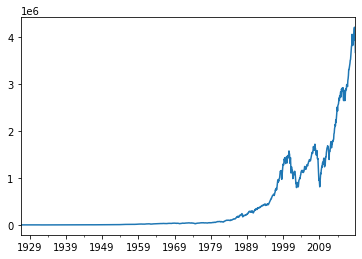

In [9]:
wealth_index.plot.line()

In [10]:
previous_peaks = wealth_index.cummax()

<AxesSubplot:>

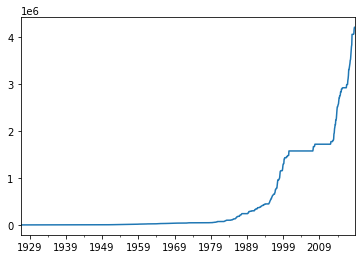

In [11]:
previous_peaks.plot()

<AxesSubplot:>

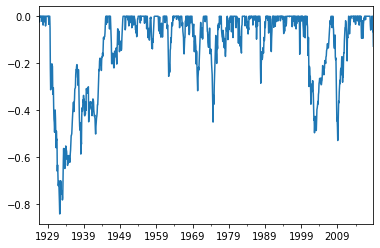

In [13]:
drawdown = (wealth_index-previous_peaks)/previous_peaks
drawdown.plot()

In [14]:
drawdown['1975':].min()

-0.5280945042309304

In [17]:
drawdown['1975':].idxmin()

Period('2009-02', 'M')

In [31]:
def drawdown_compute(returns_series: pd.Series):
    """
    it takes a timeseries of asset returns computes and sends back a df with : wealth index , previous peaks , pct drawdown
    """
    wealth_index = 1000*(1+returns_series).cumprod()
    previous_peaks = wealth_index.cummax()
    drawdowns = (wealth_index-previous_peaks)/previous_peaks
    return pd.DataFrame({'wealth index':wealth_index , 'previous peaks':previous_peaks , 'drawdowns':drawdowns})

In [32]:
col_3_df = drawdown_compute(rets['Largecap'])
col_3_df.head()

,wealth index,previous peaks,drawdowns
1926-07,1032.900000,1032.900000,0.0000
1926-08,1071.117300,1071.117300,0.0000
1926-09,1078.293786,1078.293786,0.0000
1926-10,1052.091247,1078.293786,-0.0243
1926-11,1080.497711,1080.497711,0.0000


In [33]:
wealth_prepeaks = col_3_df[['wealth index','previous peaks']]
wealth_prepeaks

,wealth index,previous peaks
1926-07,1.032900e+03,1.032900e+03
1926-08,1.071117e+03,1.071117e+03
1926-09,1.078294e+03,1.078294e+03
1926-10,1.052091e+03,1.078294e+03
1926-11,1.080498e+03,1.080498e+03
...,...,...
2018-08,4.175915e+06,4.175915e+06
2018-09,4.212246e+06,4.212246e+06
2018-10,3.935501e+06,4.212246e+06
2018-11,4.035069e+06,4.212246e+06


<AxesSubplot:>

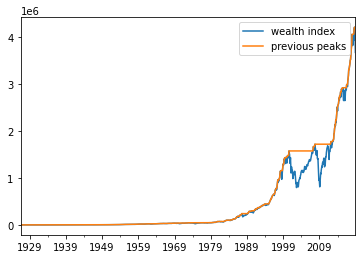

In [34]:
wealth_prepeaks.plot()